In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, optimizers
import tensorflow_datasets as tfds

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cmaterdb/devanagari/incomplete.HDMVX4_1.0.0/cmaterdb-train.tfrecord*...:  …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cmaterdb/devanagari/incomplete.HDMVX4_1.0.0/cmaterdb-test.tfrecord*...:   …

Dataset cmaterdb downloaded and prepared to /root/tensorflow_datasets/cmaterdb/devanagari/1.0.0. Subsequent calls will reuse this data.
Dataset Info:
Training samples: 2500
Test samples: 500
Image shape: (32, 32, 3)
Number of classes: 10


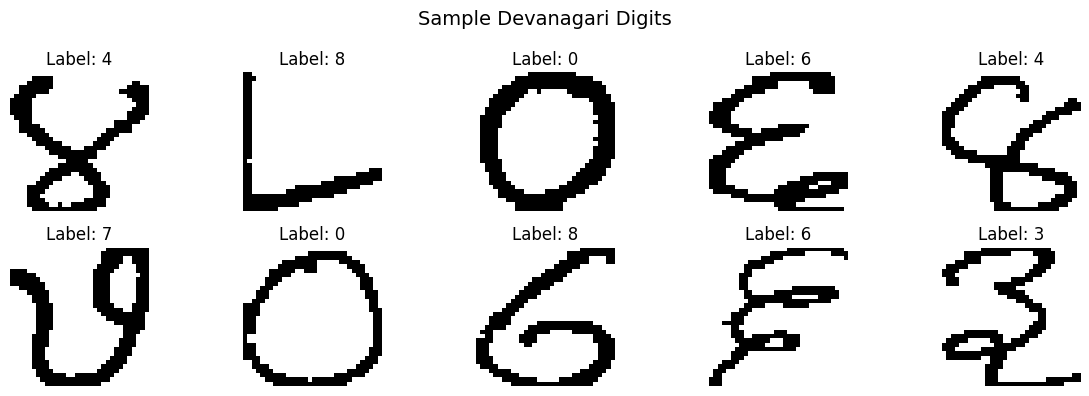

In [ ]:
# This dataset contains 32x32 RGB images of Devanagari numerals (0-9)
(ds_train, ds_test), ds_info = tfds.load(
    'cmaterdb/devanagari',
    split=['train', 'test'],
    shuffle_files=True,
    as_supervised=True,  # Returns (image, label) pairs
    with_info=True,
)

print("Dataset Info:")
print(f"Training samples: {ds_info.splits['train'].num_examples}")
print(f"Test samples: {ds_info.splits['test'].num_examples}")
print(f"Image shape: {ds_info.features['image'].shape}")
print(f"Number of classes: {ds_info.features['label'].num_classes}")

# Display sample images from the dataset
plt.figure(figsize=(12, 4))
for i, (image, label) in enumerate(ds_train.take(10)):
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(image.numpy().astype("uint8"))
    plt.title(f"Label: {label.numpy()}")
    plt.axis("off")
plt.suptitle("Sample Devanagari Digits", fontsize=14)
plt.tight_layout()
plt.show()

Training data shape: (2500, 28, 28, 1)
Test data shape: (500, 28, 28, 1)
Min value: 0.0000, Max value: 1.0000


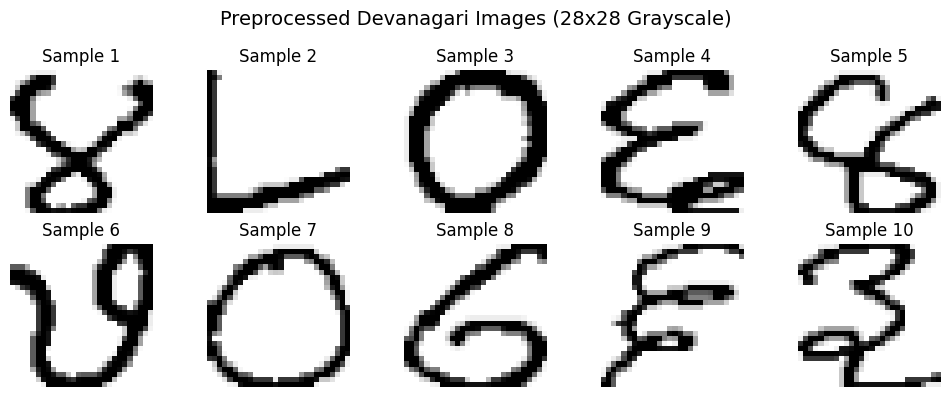

In [ ]:
# Preprocessing function: Convert to grayscale, normalize, and resize
def preprocess(image, label):
    # Convert RGB to grayscale (take mean across channels)
    image = tf.image.rgb_to_grayscale(image)
    # Resize to 28x28 (standard size similar to MNIST)
    image = tf.image.resize(image, [28, 28])
    # Normalize to [0, 1] range
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Apply preprocessing to the datasets
BATCH_SIZE = 128

# Training dataset
x_train = ds_train.map(lambda image, label: preprocess(image, label))
x_train = x_train.map(lambda image, label: image)
x_train = x_train.cache().batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Test dataset
x_test = ds_test.map(lambda image, label: preprocess(image, label))
x_test = x_test.map(lambda image, label: image)  # Keep only images
x_test = x_test.cache().batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Convert to numpy arrays for easier manipulation
x_train_np = []
for batch in x_train:
    x_train_np.extend(batch.numpy())
x_train_np = np.array(x_train_np)

x_test_np = []
for batch in x_test:
    x_test_np.extend(batch.numpy())
x_test_np = np.array(x_test_np)

print(f"Training data shape: {x_train_np.shape}")
print(f"Test data shape: {x_test_np.shape}")
print(f"Min value: {x_train_np.min():.4f}, Max value: {x_train_np.max():.4f}")

# Visualize preprocessed images
plt.figure(figsize=(10, 4))
for i in range(10):
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_np[i].reshape(28, 28), cmap='gray')
    plt.title(f"Sample {i+1}")
    plt.axis("off")
plt.suptitle("Preprocessed Devanagari Images (28x28 Grayscale)", fontsize=14)
plt.tight_layout()
plt.show()

Noisy training data shape: (2500, 28, 28, 1)
Noisy test data shape: (500, 28, 28, 1)


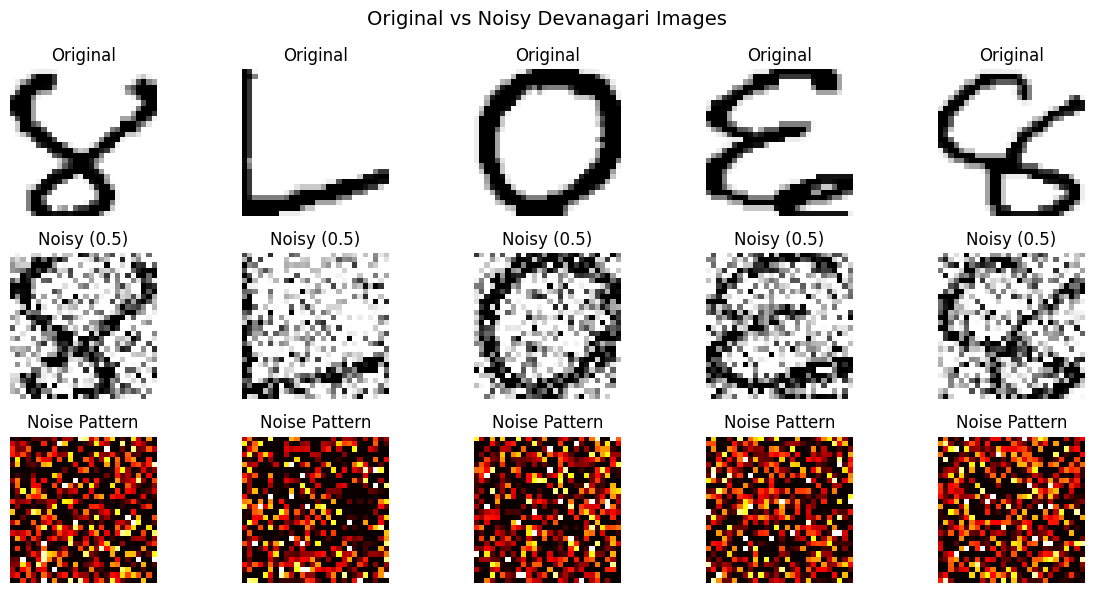

In [ ]:
noise_factor = 0.5
# Generate noisy training images
x_train_noisy = x_train_np + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_train_np.shape
)

# Generate noisy test images
x_test_noisy = x_test_np + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_test_np.shape
)

# Clip pixel values to ensure they remain in [0, 1] range
x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
x_test_noisy = np.clip(x_test_noisy, 0.0, 1.0)

print(f"Noisy training data shape: {x_train_noisy.shape}")
print(f"Noisy test data shape: {x_test_noisy.shape}")

# Visualize original vs noisy images
n = 5  # Number of images to display
plt.figure(figsize=(12, 6))
for i in range(n):
    # Original image
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_train_np[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy image
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_train_noisy[i].reshape(28, 28), cmap='gray')
    plt.title(f"Noisy (0.5)")
    plt.axis('off')

    # Difference
    ax = plt.subplot(3, n, i + 1 + 2*n)
    diff = np.abs(x_train_noisy[i] - x_train_np[i])
    plt.imshow(diff.reshape(28, 28), cmap='hot')
    plt.title("Noise Pattern")
    plt.axis('off')

plt.suptitle("Original vs Noisy Devanagari Images", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Input: 28x28x1 grayscale images
input_img = layers.Input(shape=(28, 28, 1), name="input")

x = layers.Conv2D(32, (3, 3), activation='relu', padding='same', name="enc_conv1")(input_img)
x = layers.MaxPooling2D((2, 2), padding='same', name="enc_pool1")(x)  # 14x14x32

x = layers.Conv2D(64, (3, 3), activation='relu', padding='same', name="enc_conv2")(x)
x = layers.MaxPooling2D((2, 2), padding='same', name="enc_pool2")(x)  # 7x7x64

x = layers.Conv2D(128, (3, 3), activation='relu', padding='same', name="enc_conv3")(x)
x = layers.MaxPooling2D((2, 2), padding='same', name="enc_pool3")(x)  # 4x4x128

encoded = layers.Conv2D(256, (3, 3), activation='relu', padding='same', name="encoded")(x)

# Create encoder model
encoder = Model(input_img, encoded, name="encoder")
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv1 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool1 (MaxPooling2D)        │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv2 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool2 (MaxPooling2D)        │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv3 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool3 (MaxPooling2D)        │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (Conv2D)                │ (None, 4, 4, 256)      │       295,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 387,840 (1.48 MB)

 Trainable params: 387,840 (1.48 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
decoder_input = layers.Input(shape=(4, 4, 256), name="decoder_input")

# Layer 1: Conv2D with 128 filters + Upsampling
x = layers.Conv2D(128, (3, 3), activation='relu', padding='same', name="dec_conv1")(decoder_input)
x = layers.UpSampling2D((2, 2), name="dec_up1")(x)  # 8x8x128

# Layer 2: Conv2D with 64 filters + Upsampling
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same', name="dec_conv2")(x)
x = layers.UpSampling2D((2, 2), name="dec_up2")(x)  # 16x16x64

# Layer 3: Conv2D with 32 filters + Upsampling
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same', name="dec_conv3")(x)
x = layers.UpSampling2D((2, 2), name="dec_up3")(x)  # 32x32x32

# Layer 4: Final Conv2D with 1 filter (grayscale output) + Cropping to 28x28
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same', name="dec_conv4")(x)
# Crop to match original size (28x28)
x = layers.Cropping2D(((2, 2), (2, 2)), name="crop")(x)  # 28x28x32
decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="decoded")(x)

# Create decoder model
decoder = Model(decoder_input, decoded, name="decoder")
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv1 (Conv2D)              │ (None, 4, 4, 128)      │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up1 (UpSampling2D)          │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv2 (Conv2D)              │ (None, 8, 8, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up2 (UpSampling2D)          │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv3 (Conv2D)              │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up3 (UpSampling2D)          │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv4 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ crop (Cropping2D)               │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 396,833 (1.51 MB)

 Trainable params: 396,833 (1.51 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Build the complete autoencoder by connecting encoder and decoder
autoencoder_input = layers.Input(shape=(28, 28, 1), name="autoencoder_input")
encoded_output = encoder(autoencoder_input)
decoded_output = decoder(encoded_output)

autoencoder = Model(autoencoder_input, decoded_output, name="denoising_autoencoder")

# Compile the model with Adam optimizer and Binary Crossentropy loss
autoencoder.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy'
)

# Display model architecture
autoencoder.summary()

# Visualize the model architecture
from tensorflow.keras.utils import plot_model
plot_model(autoencoder, to_file='autoencoder_architecture.png', show_shapes=True, show_layer_names=True)
print("\nArchitecture saved as 'autoencoder_architecture.png'")

Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ autoencoder_input (InputLayer)  │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 4, 4, 256)      │       387,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 28, 28, 1)      │       396,833 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 784,673 (2.99 MB)

 Trainable params: 784,673 (2.99 MB)

 Non-trainable params: 0 (0.00 B)


Model architecture saved as 'autoencoder_architecture.png'


In [ ]:
# Train the autoencoder
# Input: Noisy images, Target: Clean images

EPOCHS = 30
BATCH_SIZE = 128

print("Starting training...")
history = autoencoder.fit(
    x_train_noisy, x_train_np,  # Noisy input, clean target
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(x_test_noisy, x_test_np),  # Validation on test set
    verbose=1
)

print("\nTraining completed!")

Starting training...
Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - loss: 0.6442 - val_loss: 0.6125
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - loss: 0.5977 - val_loss: 0.6010
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - loss: 0.5854 - val_loss: 0.5621
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - loss: 0.5339 - val_loss: 0.4764
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - loss: 0.4327 - val_loss: 0.3997
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - loss: 0.3615 - val_loss: 0.3255
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - loss: 0.3032 - val_loss: 0.2809
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - loss: 0.2701 - val_loss: 0.2583
Epoch 9/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - loss: 0.2489 - val_loss: 0.2413
Epoch 10/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - loss: 0.2348 - val_loss: 0.2332
Epoch 11/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - loss: 0.2249 - val_loss: 0.2265
Epoch 12/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - 

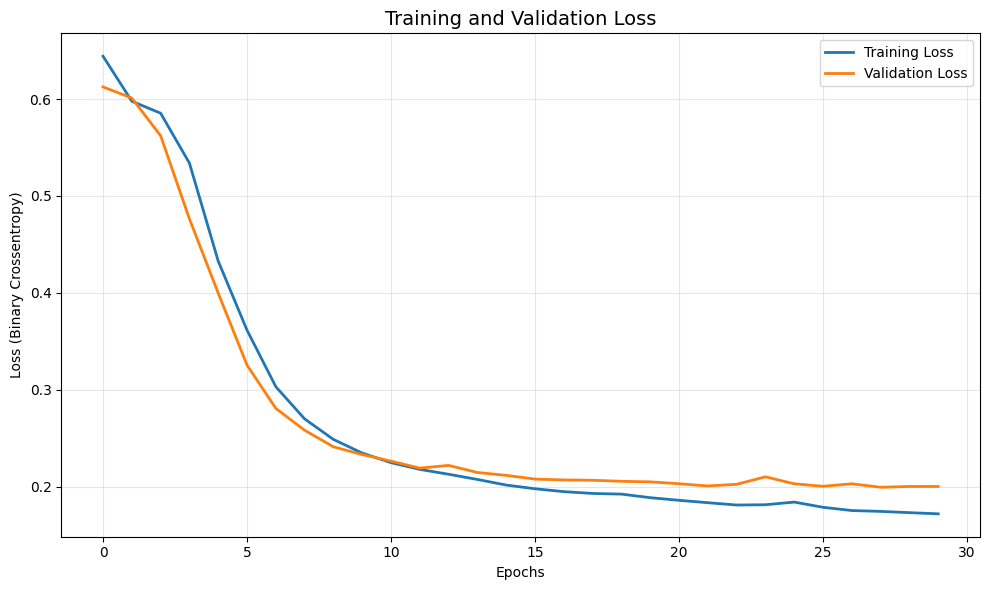

Final Training Loss: 0.172120
Final Validation Loss: 0.200334


In [ ]:
# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss (Binary Crossentropy)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print final loss values
print(f"Final Training Loss: {history.history['loss'][-1]:.6f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.6f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step


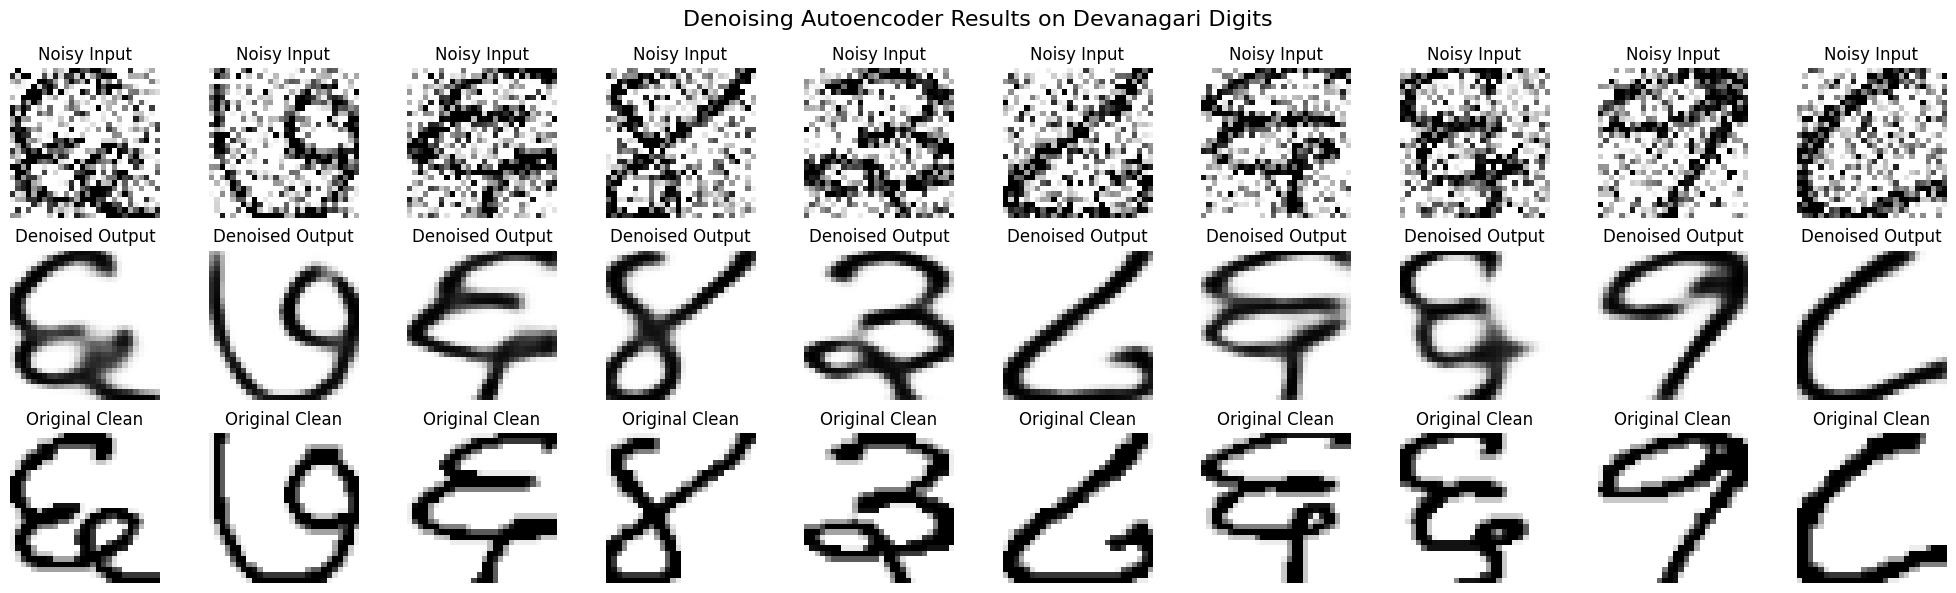

In [ ]:
# Use the trained autoencoder to denoise test images
denoised_images = autoencoder.predict(x_test_noisy)

# Function to display comparison
def plot_denoising_results(noisy, denoised, clean, n=10):
    plt.figure(figsize=(20, 6))

    for i in range(n):
        # Noisy image
        ax = plt.subplot(3, n, i + 1)
        plt.imshow(noisy[i].reshape(28, 28), cmap='gray')
        plt.title("Noisy Input")
        plt.axis('off')

        # Denoised image
        ax = plt.subplot(3, n, i + 1 + n)
        plt.imshow(denoised[i].reshape(28, 28), cmap='gray')
        plt.title("Denoised Output")
        plt.axis('off')

        # Clean original
        ax = plt.subplot(3, n, i + 1 + 2*n)
        plt.imshow(clean[i].reshape(28, 28), cmap='gray')
        plt.title("Original Clean")
        plt.axis('off')

    plt.suptitle('Denoising Autoencoder Results on Devanagari Digits', fontsize=16)
    plt.tight_layout()
    plt.show()

# Display results for 10 test images
plot_denoising_results(x_test_noisy, denoised_images, x_test_np, n=10)

Mean Squared Error (Noisy vs Clean): 0.116642
Mean Squared Error (Denoised vs Clean): 0.030978
Improvement: 73.44%


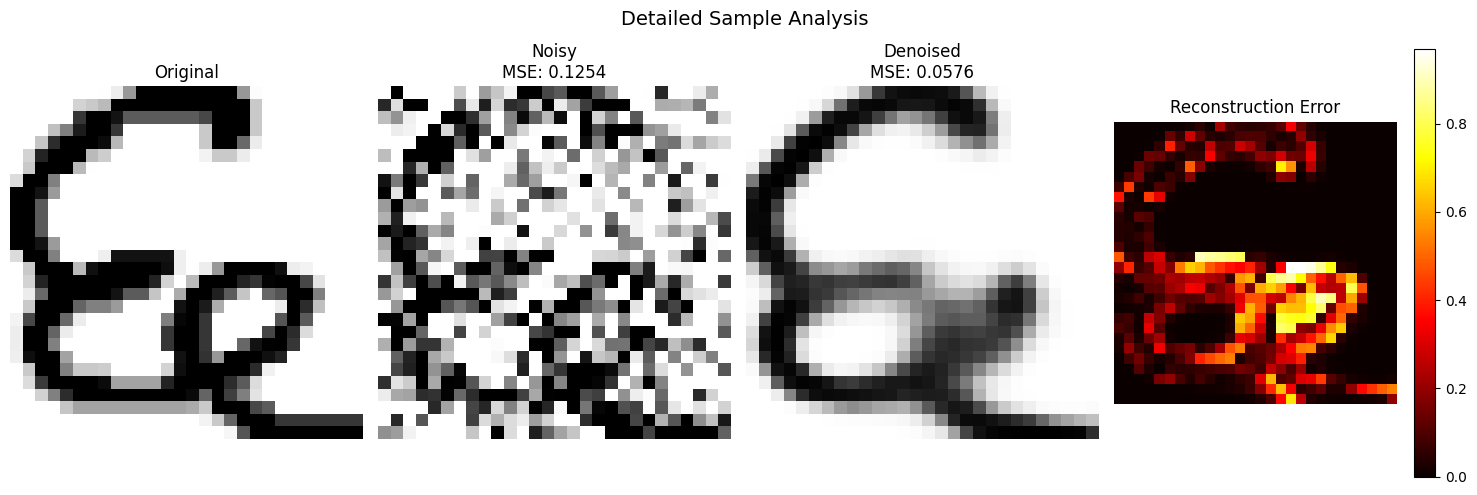

In [ ]:
from sklearn.metrics import mean_squared_error

# MSE between noisy and clean (before denoising)
mse_noisy = mean_squared_error(x_test_np.flatten(), x_test_noisy.flatten())

# MSE between denoised and clean (after denoising)
mse_denoised = mean_squared_error(x_test_np.flatten(), denoised_images.flatten())

print(f"Mean Squared Error (Noisy vs Clean): {mse_noisy:.6f}")
print(f"Mean Squared Error (Denoised vs Clean): {mse_denoised:.6f}")
print(f"Improvement: {(mse_noisy - mse_denoised) / mse_noisy * 100:.2f}%")

# Visualize the difference
plt.figure(figsize=(15, 5))

# Sample image comparison
sample_idx = 0
plt.subplot(1, 4, 1)
plt.imshow(x_test_np[sample_idx].reshape(28, 28), cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(x_test_noisy[sample_idx].reshape(28, 28), cmap='gray')
plt.title(f"Noisy\nMSE: {mean_squared_error(x_test_np[sample_idx].flatten(), x_test_noisy[sample_idx].flatten()):.4f}")
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(denoised_images[sample_idx].reshape(28, 28), cmap='gray')
plt.title(f"Denoised\nMSE: {mean_squared_error(x_test_np[sample_idx].flatten(), denoised_images[sample_idx].flatten()):.4f}")
plt.axis('off')

plt.subplot(1, 4, 4)
# Error map
error = np.abs(x_test_np[sample_idx] - denoised_images[sample_idx])
plt.imshow(error.reshape(28, 28), cmap='hot')
plt.title("Reconstruction Error")
plt.axis('off')
plt.colorbar()

plt.suptitle("Detailed Sample Analysis", fontsize=14)
plt.tight_layout()
plt.show()